# “Unlocking Profits: Ranking Product Categories and Customer Segments to spot top products and customers, boost marketing impact, plan inventory smarter”

In [18]:
# 1) Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# loading the data set
df = pd.read_csv(r"C:\Users\thaneshwar\Downloads\shopping_behavior_updated (1).csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,No,24,Venmo,Weekly


In [20]:
# clean data
df.columns = df.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
df

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Discount_Applied,Previous_Purchases,Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,No,24,Venmo,Weekly


In [21]:
print(df.shape)


(3900, 16)


In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item_Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase_Amount_USD     3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review_Rating           3900 non-null   float64
 11  Subscription_Status     3900 non-null   object 
 12  Discount_Applied        3900 non-null   object 
 13  Previous_Purchases      3900 non-null   int64  
 14  Payment_Method          3900 non-null   

In [23]:
df.duplicated().any().sum()


0

In [24]:
df['Review_Rating'].isnull().sum()

0

In [25]:
# 6) Univariate Analysis (Non-Visual)
print("Category Counts:\n", df["Category"].value_counts())
print("Gender Counts:\n", df["Gender"].value_counts())
print("Season Counts:\n", df["Season"].value_counts())
print("Purchase_Amount_USD:\n", df["Purchase_Amount_USD"].sum())

Category Counts:
 Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64
Gender Counts:
 Gender
Male      2652
Female    1248
Name: count, dtype: int64
Season Counts:
 Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64
Purchase_Amount_USD:
 233081


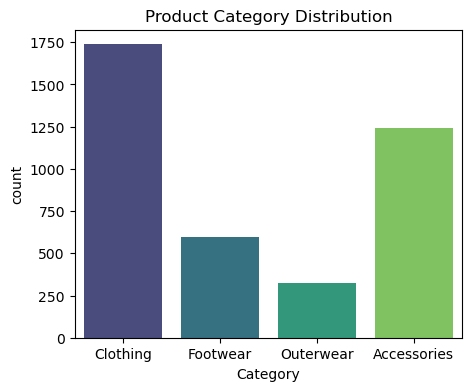

In [26]:
# 7) Univariate Analysis (Visual)
plt.figure(figsize=(5,4))
sns.countplot(x="Category", data=df, hue="Category", palette="viridis", legend=False)
plt.title("Product Category Distribution")
plt.show()

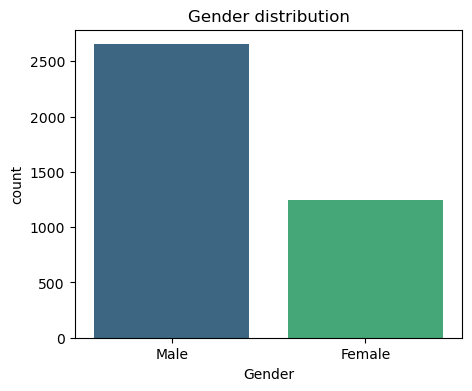

In [27]:
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", data=df, hue="Gender", palette="viridis", legend=False)
plt.title("Gender distribution")
plt.show()

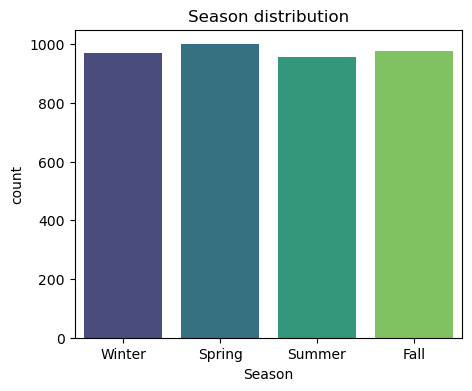

In [28]:
plt.figure(figsize=(5,4))
sns.countplot(x="Season", data=df, hue="Season", palette="viridis", legend=False)
plt.title("Season distribution")
plt.show()

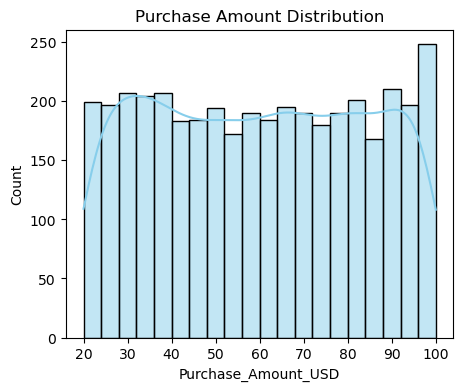

In [13]:
plt.figure(figsize=(5,4))
sns.histplot(df["Purchase_Amount_USD"], bins=20, kde=True, color="skyblue")
plt.title("Purchase Amount Distribution")
plt.show()

In [14]:
# 8) Bivariate Analysis (Non-Visual)
category_sales = df.groupby("Category")["Purchase_Amount_USD"].sum().sort_values(ascending=False)
print("Revenue by Category:\n", category_sales)

gender_avg = df.groupby("Gender")["Purchase_Amount_USD"].mean()
print("Average Spend by Gender:\n", gender_avg)

Revenue by Category:
 Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase_Amount_USD, dtype: int64
Average Spend by Gender:
 Gender
Female    60.249199
Male      59.536199
Name: Purchase_Amount_USD, dtype: float64


In [29]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)
age_sales = df.groupby("Age_Group", observed=True)["Purchase_Amount_USD"].sum().sort_values(ascending=False)
print("Revenue by Age Group:\n", age_sales)

Revenue by Age Group:
 Age_Group
26-35    45400
46-55    45370
56-65    44096
36-45    43463
18-25    29258
Name: Purchase_Amount_USD, dtype: int64


# 9) Bivariate Analysis (Visual)

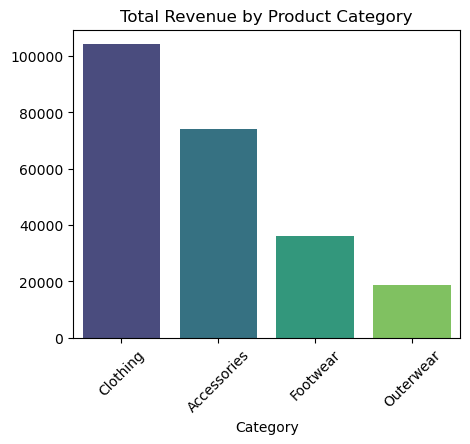

In [30]:
plt.figure(figsize=(5,4))
sns.barplot(x=category_sales.index, y=category_sales.values,
hue=category_sales.index, palette="viridis", legend=False)
plt.title("Total Revenue by Product Category")
plt.xticks(rotation=45)
plt.show()

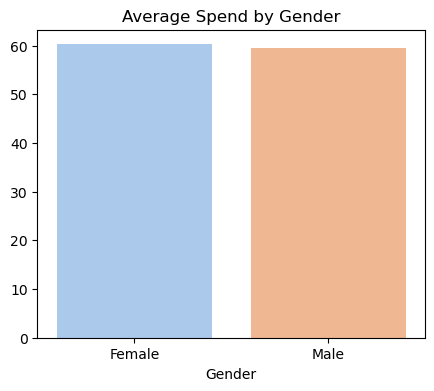

In [31]:
plt.figure(figsize=(5,4))
sns.barplot(x=gender_avg.index, y=gender_avg.values,
hue=gender_avg.index, palette="pastel", legend=False)
plt.title("Average Spend by Gender")
plt.show()

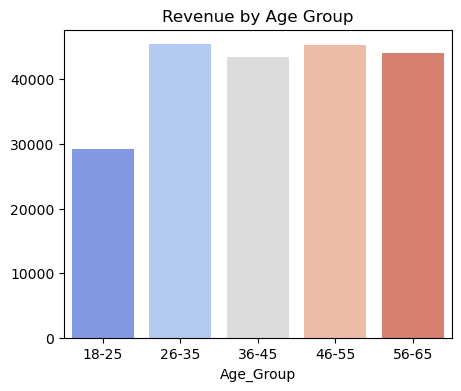

In [32]:
plt.figure(figsize=(5,4))
sns.barplot(x=age_sales.index, y=age_sales.values, hue=age_sales.index, palette="coolwarm", legend=False)

plt.title("Revenue by Age Group")
plt.show()

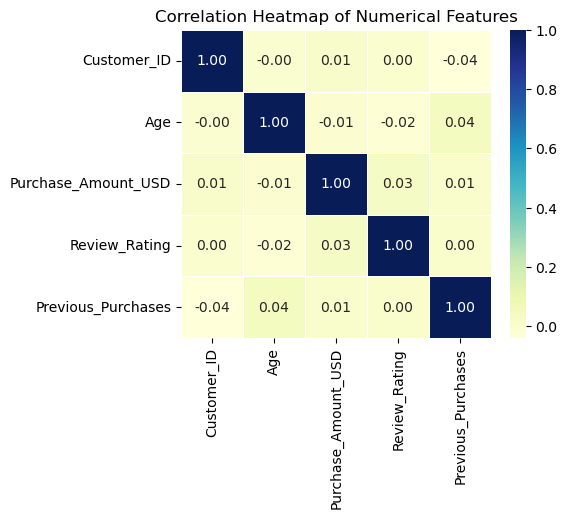

In [19]:
# 12) Heatmap: Correlation Between Numerical Features
numeric_cols = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


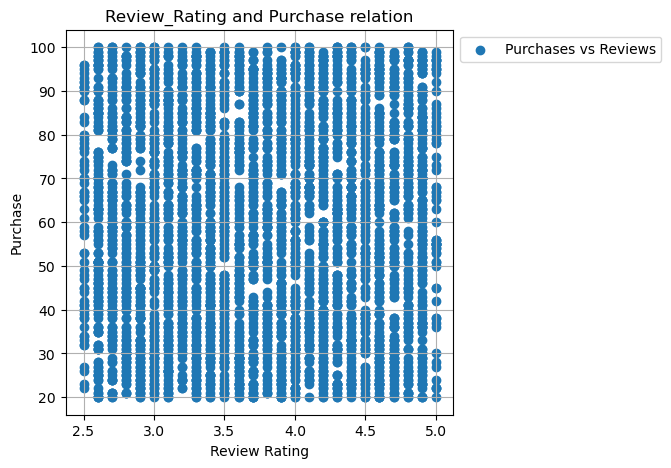

In [33]:
plt.figure(figsize=(5,5))
plt.scatter(df['Review_Rating'], df['Purchase_Amount_USD'], label="Purchases vs Reviews")

plt.title('Review_Rating and Purchase relation')
plt.xlabel('Review Rating')
plt.ylabel('Purchase')

plt.legend(bbox_to_anchor=(1,1))
plt.grid(True)
plt.show()

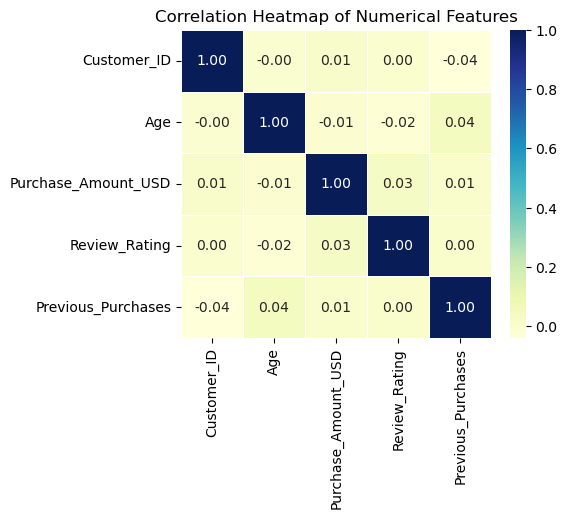

In [21]:
numeric_cols = df.select_dtypes(include=["int64","float64"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


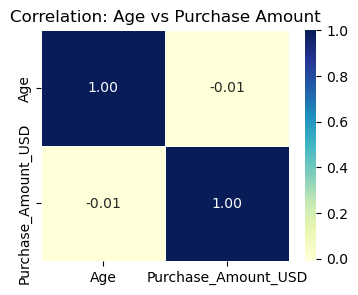

In [22]:
# Select only the two numerical columns
numeric_cols = df[['Age', 'Purchase_Amount_USD']]

# Compute correlation
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(4,3))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Age vs Purchase Amount")
plt.show()


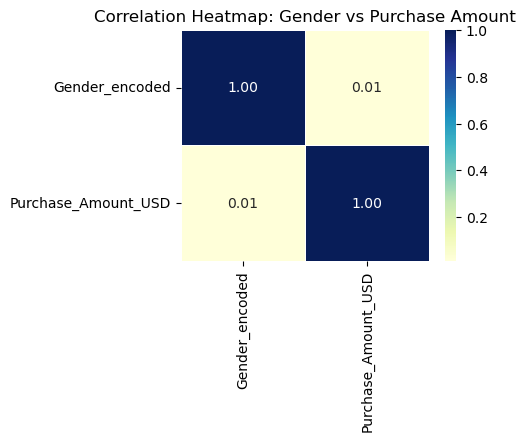

In [24]:
# Encode categorical variable
df['Gender_encoded'] = df['Gender'].map({'Male':0, 'Female':1})

# Select numerical + encoded categorical
numeric_cols = df[['Gender_encoded', 'Purchase_Amount_USD']]

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Heatmap
plt.figure(figsize=(4,3))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Gender vs Purchase Amount")
plt.show()
